In [1]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import xarray as xr
import os
import torch
from utils import ELEMENTS_NAMES
from train import load_datasets, load_dataset
from models import load_nn
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

ELEMENTS_NAMES['era5'] = 'Водный эквивалент снега (ERA5)'

figures_dir = "../figures/presentation"

os.makedirs(figures_dir, exist_ok=True)
pd.set_option('display.max_rows', 500)
dpi = 150

In [4]:
dsTrain, dsTest = load_datasets("swe_6_7_3_seqmap")
X_train, y_train,  _ = dsTrain.load_all()
X_test,  y_test,  _ = dsTest.load_all()

In [9]:
#X_train.shape
y_train[0, :, :, :].shape
zero_count = (torch.sum(y_train[0, :, :, :] == 0, dim=(1,2)) == 61*117).sum().item()
print(f"Количество полностью нулевых матриц: {zero_count}")

Количество полностью нулевых матриц: 0


In [25]:
#(torch.sum(torch.abs(y_train[0, :, :, :]), dim=(1,2)) < 100).sum().item()
y_test.shape

torch.Size([4, 1534, 61, 117])

In [2]:
era_ds = xr.open_dataset(f"../data/climate/week/era5_swe/01.nc", engine="h5netcdf")
globsnow_ds = xr.open_dataset(f"../data/climate/week/globsnow/01.nc", engine="h5netcdf")
mask = xr.open_dataset(f"../data/prepare/time_invariant.nc", engine="h5netcdf").lsm.values > 0.5
lat, lon = era_ds.lat.values, era_ds.lon.values

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

values_era = np.minimum(era_ds["swe_mean"].values, 150)
values_globsnow = np.minimum(globsnow_ds["swe_mean"].values, 150)
values_diff = values_era - values_globsnow

norm = plt.Normalize(vmin=0, vmax=150)
norm_diff = plt.Normalize(vmin=-40, vmax=40)

for ax, data in zip(axes[:2], [values_era, values_globsnow]):
    mesh = ax.pcolormesh(lon, lat, data, cmap='viridis', norm=norm, 
                         alpha=mask, shading='nearest')
    ax.set_xlim([20, 60])
    ax.set_ylim([45, 70])

mesh_diff = axes[2].pcolormesh(lon, lat, values_diff, cmap='RdBu_r', norm=norm_diff,
                               alpha=mask, shading='nearest')
axes[2].set_xlim([20, 60])
axes[2].set_ylim([45, 70])

axes[0].set_title('ERA5')
axes[1].set_title('Globsnow')
axes[2].set_title('ERA5 - Globsnow')
axes[1].set_yticks([])
axes[2].set_yticks([])

fig.colorbar(mesh, ax=axes[:2], orientation='horizontal', label='мм', aspect=40, shrink=0.8)
fig.colorbar(mesh_diff, ax=axes[2], orientation='horizontal', label='мм', shrink=0.8)
plt.savefig(f'{figures_dir}/img1.png', dpi=dpi, bbox_inches='tight')
plt.close(fig)

In [4]:
dsTrain, dsTest = load_datasets("swe_4_2_3_point")
X_train, y_train, _ = dsTrain.load_all()
X_test,  y_test,  _ = dsTest.load_all()
X = torch.cat([X_train, X_test], dim=0)
y = torch.cat([y_train, y_test], dim=0)
data = torch.cat([X[:, :14], y.unsqueeze(1)], dim=1)
df = pd.DataFrame(data, columns=(dsTrain.variables[:14] + ['era5']))
corr = df.corr()
var_order = ['swe', 'era5', 'prec', 'rq2',
                 'ww', 't850', 't2min', 't2', 't2max', 'olr', 'ps', 'u850', 'v850', 'uv10']
corr = corr.loc[var_order, var_order]
corr = corr.rename(index=ELEMENTS_NAMES, columns=ELEMENTS_NAMES)
fig = plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=2, linecolor='white',
            square=True, xticklabels=False, cbar=False,  annot_kws={'size': 11})
plt.savefig(f'{figures_dir}/img2.png', dpi=dpi, bbox_inches='tight')
plt.close(fig)

del df

In [4]:
from datetime import datetime, timedelta

def days_diff(week, lead_months, year=2005):
    target = datetime(year, 1, 1) + timedelta(weeks=int(week)-1)
    forecast = target.replace(day=1)
    for _ in range(int(lead_months)):
        if forecast.month == 1:
            forecast = forecast.replace(year=forecast.year-1, month=12)
        else:
            forecast = forecast.replace(month=forecast.month-1)
    return (target - forecast).days // 7

weeks = np.arange(1, 53)
leads = np.arange(1, 4)
week_matrix = np.repeat(weeks, len(leads))
lead_matrix = np.tile(leads, len(weeks))
all_values = np.array([days_diff(w, l) for w, l in zip(week_matrix, lead_matrix)])
lookup_matrix = all_values.reshape(len(weeks), len(leads))
period_idx = df['period'].values.astype(int) - 1
lead_idx = df['lead_time'].values.astype(int) - 1
df['lead_weeks'] = lookup_matrix[period_idx, lead_idx]

In [2]:
def load_all(name, dim=0):
    dsTrain, dsTest = load_datasets(name)
    X_train, y_train,  _ = dsTrain.load_all()
    X_test,  y_test,  _ = dsTest.load_all()
    X = torch.cat([X_train, X_test], dim=dim)
    y = torch.cat([y_train, y_test], dim=dim)
    return X, y, dsTest.variables

def make_data(name):
    X, y, variables = load_all(name)
    return torch.cat([X, y.unsqueeze(1)], dim=1), variables

In [3]:
ds = xr.open_dataset('../data/train/swe/std.nc', engine='h5netcdf')
df_std = ds['swe'].to_dataframe().reset_index().rename(columns={'swe': 'std'})

In [4]:
dfs = []

data, variables = make_data("swe_4_3_3_point")
df = pd.DataFrame(data, columns=(variables + ['era5']))
df['year'] = df['year']*10 + 2005
dfs.append(df)

data, variables = make_data("swe_4_4_3_point")
df2 = pd.DataFrame(data, columns=(variables + ['era5']))
df2['year'] = df2['year']*10 + 2005
dfs.append(df2)

df3 = xr.open_dataset('../data/prepare/swe_seas/all.nc', engine='h5netcdf').to_dataframe().reset_index()
df3 = df3[['swe', 'year', 'week', 'lead_time', 'lat', 'lon']].rename(columns={'week': 'period'})
df3 = df3.merge(df[['year', 'period', 'lead_time', 'lat', 'lon', 'era5']], on=['year', 'period', 'lead_time', 'lat', 'lon'], how='inner')
clim = df3.groupby(['period', 'lat', 'lon'])['swe'].mean().reset_index().rename(columns={'swe': 'swe_clim'})
df3 = df3.merge(clim, on=['period', 'lat', 'lon'], how='left')
df3['swe'] = df3['swe'] - df3['swe_clim']
dfs.append(df3)

In [5]:
X, _, _ = load_all(f"swe_4_6_3_seqmap", dim=1)
lats = X[-1, :, :, :, 0].reshape(-1, 1)
lons = X[-1, :, :, :, 1].reshape(-1, 1)
lead_times = X[-1, :, :, :, 2].reshape(-1, 1)

In [6]:
X, y, _ = load_all("swe_4_7_3_seqmap", dim=1)
model = load_nn(f"../data/experiments/swe_etr_seqmap_v3_spring")
y_pred = model.predict(X)
data = torch.cat([y[-1, :, :, :].reshape(-1, 1), y_pred.reshape(-1, 1), lead_times, X[-1, :, :, :, -1].reshape(-1, 1)], dim=1)
df4 = pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'year']))
df4['year'] = df4['year']*10 + 2005
dfs.append(df4)

In [7]:
X, y, _ = load_all("swe_4_3_3_seqmap", dim=1)
model = load_nn(f"../data/experiments/swe_etr_seqmap_with_era_spring")
y_pred = model.predict(X)
data = torch.cat([y[-1, :, :, :].reshape(-1, 1), y_pred.reshape(-1, 1), lead_times, X[-1, :, :, :, -2].reshape(-1, 1)], dim=1)
df5 = pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'year']))
df5['year'] = df5['year']*10 + 2005
dfs.append(df5)

In [8]:
X, y, variables = load_all("swe_4_4_3_seqmap", dim=1)
data = torch.cat([y[-1, :, :, :].reshape(-1, 1), X[-1, :, :, :, 0].reshape(-1, 1), lead_times, X[-1, :, :, :, -1].reshape(-1, 1)], dim=1)
df6 = pd.DataFrame(data, columns=(['era5', 'swe', 'lead_time', 'year']))
df6['year'] = df6['year']*10 + 2005
dfs.append(df6)

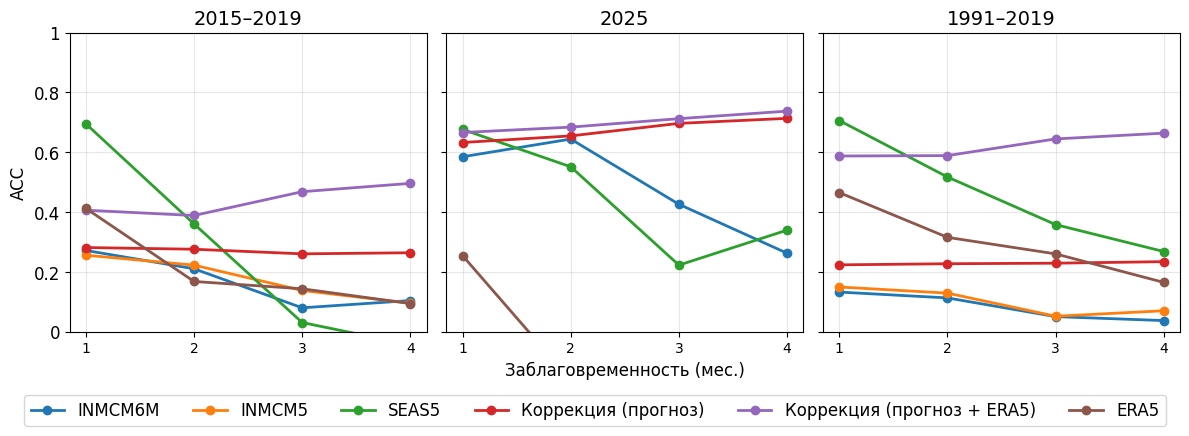

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
names = ['INMCM6M', 'INMCM5', 'SEAS5', 'Коррекция (прогноз)', 'Коррекция (прогноз + ERA5)', 'ERA5']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

periods = [(2015, 2019), (2025, 2025), (1991, 2019)]
titles = ['2015–2019', '2025', '1991–2019']

for idx, (min_year, max_year) in enumerate(periods):
    ax = axes[idx]
    
    for df, name, color in zip(dfs, names, colors):
        df_ = df[(df['year'] >= min_year) & (df['year'] <= max_year)]
        if len(df_) < 100:
            continue
            
        corr = df_.groupby('lead_time').apply(
            lambda x: x['swe'].corr(x['era5']),
            include_groups=False
        ).reset_index(name='corr')
        
        ax.plot(corr['lead_time'], corr['corr'], 'o-', color=color, linewidth=2)
    
    ax.set_title(titles[idx], fontsize=14)
    if idx == 1:
        ax.set_xlabel('Заблаговременность (мес.)', fontsize=12)
    ax.set_ylabel('ACC' if idx == 0 else '', fontsize=12)
    if idx == 0:
        ax.set_yticks(np.arange(0, 1.1, 0.2))
        ax.set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1'], fontsize=12)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['1', '2', '3', '4'])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

fig.legend(names, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=len(names), fontsize=12)
plt.tight_layout()
plt.savefig(f'{figures_dir}/img3.png', dpi=dpi, bbox_inches='tight')
plt.show()

In [19]:
def load_all(name, dim=0):
    dsTrain, dsTest = load_datasets(name)
    X_train, y_train,  _ = dsTrain.load_all()
    X_test,  y_test,  _ = dsTest.load_all()
    X = torch.cat([X_train, X_test], dim=dim)
    y = torch.cat([y_train, y_test], dim=dim)
    return X, y, dsTest.variables

def make_data(name):
    X, y, variables = load_all(name)
    return torch.cat([X, y.unsqueeze(1)], dim=1), variables

dfs = []

data, variables = make_data("swe_6_3_3_point")
df = pd.DataFrame(data, columns=(variables + ['era5']))
df['year'] = df['year']*10 + 2005

In [62]:
df = df3

In [63]:
clims = []
for i in range(1, 53):
    ds = xr.open_dataset(f'../data/climate/week/era5_swe/{i:02d}.nc', engine='h5netcdf')
    clim = ds['swe_mean'].to_dataframe(name='clim').reset_index()
    clim['period'] = i
    clims.append(clim)
clim = pd.concat(clims)
df = df.merge(clim, on=['period', 'lat', 'lon'], how='inner')
df['swe'] += df['clim']
df['era5'] += df['clim']

In [68]:
moscow = df[(df['lat'] == 55.75) & (df['lon'] == 38.00) & (df['year'] != 2024) & (df['lead_time'] == 0) & (df['period'] >= 10)].copy()

In [30]:
melted1[melted1['year'] == 2007]

,swe,period,year,lead_time,lat,lon,era5,clim
14272757,32.103519,1.0,2007.0,0.0,55.75,38.0,3.360748,29.161758
14278733,14.033901,1.0,2007.0,1.0,55.75,38.0,3.360748,29.161758
14284709,21.738358,1.0,2007.0,2.0,55.75,38.0,3.360748,29.161758
14290685,28.641033,1.0,2007.0,3.0,55.75,38.0,3.360748,29.161758
14296661,34.711540,2.0,2007.0,0.0,55.75,38.0,0.694614,32.782196
...,...,...,...,...,...,...,...,...
15006689,6.072188,45.0,2007.0,3.0,55.75,38.0,0.836134,2.930376
15156089,36.260841,52.0,2007.0,0.0,55.75,38.0,4.544020,24.547426
15162065,20.472727,52.0,2007.0,1.0,55.75,38.0,4.544020,24.547426
15168041,22.368986,52.0,2007.0,2.0,55.75,38.0,4.544020,24.547426


In [80]:
melted1 = moscow[moscow['era5'] < 5]
melted2 = moscow[moscow['swe'] < 5]
melted3 = moscow[moscow['clim'] < 5]

result1 = melted1.loc[melted1.groupby(['year', 'lead_time'])['period'].idxmin()].reset_index(drop=True).rename(columns={'period': 'period_era5'})
result2 = melted2.loc[melted2.groupby(['year', 'lead_time'])['period'].idxmin()].reset_index(drop=True).rename(columns={'period': 'period_swe'})
result3 = melted3.loc[melted3.groupby(['year', 'lead_time'])['period'].idxmin()].reset_index(drop=True).rename(columns={'period': 'period_clim'})

merged = pd.merge(
    result1[['year', 'lead_time', 'period_era5']],
    result2[['year', 'lead_time', 'period_swe']],
    on=['year', 'lead_time'],
    how='inner'
).sort_values('year').reset_index(drop=True)
merged = pd.merge(merged,
    result3[['year', 'lead_time', 'period_clim']],
    on=['year', 'lead_time'],
    how='inner'
).sort_values('year').reset_index(drop=True)
merged['period_clim'] = merged[merged['year'] <= 2020]['period_era5'].mean()

merged['period_diff'] = abs(merged['period_era5'] - merged['period_swe'])
merged['period_diff2'] = abs(merged['period_era5'] - merged['period_clim'])

In [81]:
merged

,year,lead_time,period_era5,period_swe,period_clim,period_diff,period_diff2
0,1991,0.0,14,14,14.827586,0,0.827586
1,1992,0.0,14,14,14.827586,0,0.827586
2,1993,0.0,15,14,14.827586,1,0.172414
3,1994,0.0,16,16,14.827586,0,1.172414
4,1995,0.0,15,11,14.827586,4,0.172414
5,1996,0.0,15,15,14.827586,0,0.172414
6,1997,0.0,14,14,14.827586,0,0.827586
7,1998,0.0,17,15,14.827586,2,2.172414
8,1999,0.0,15,15,14.827586,0,0.172414
9,2000,0.0,15,15,14.827586,0,0.172414


In [82]:
print(merged['period_diff'].mean())
print(merged['period_diff2'].mean())


0.7
0.7011494252873564


In [12]:
X, y, variables = load_all("swe_4_7_3_seqmap", dim=1)
model = load_nn(f"../data/experiments/swe_etr_seqmap_v3_spring")
X2, _, _ = load_all("swe_4_3_3_seqmap", dim=1)
model2 = load_nn(f"../data/experiments/swe_etr_seqmap_with_era_spring")
y_pred = model.predict(X)
y2_pred = model2.predict(X2)
data = torch.cat([y[-1, :, :, :].reshape(-1, 1), y_pred.reshape(-1, 1), y2_pred.reshape(-1, 1), X[-1, :, :, :, 0].reshape(-1, 1),
                  lead_times, lats, lons, X[-1, :, :, :, -1].reshape(-1, 1)], dim=1)
df4 = pd.DataFrame(data, columns=(['era5', 'swe', 'swe_era', 'swe_old', 'lead_time', 'lat', 'lon', 'year']))
ds = xr.open_dataset('../data/train/swe/std.nc', engine='h5netcdf')
df_std = ds['swe'].to_dataframe().reset_index().rename(columns={'swe': 'std'})
df4 = df4.merge(df_std, on=['lat', 'lon'])
df4['swe_old'] *= df4['std']
df4['year'] = df4['year']*10 + 2005
df4['diff'] = df4['swe'] - df4['swe_old']
df4['diff_era'] = df4['era5'] - df4['swe_old']
df4['diff_swe_era'] = df4['swe_era'] - df4['swe_old']

In [82]:
diffs = []
for i in range(4):
    df = df4[(df4['year'] > 1990+i*10) & (df4['year'] <= 2000+i*10)]
    diff = df.groupby(['lat', 'lon'])['diff'].mean().reset_index()
    diffs.append(diff)

In [67]:
diffs = []
for i in range(4):
    df = df4[(df4['year'] > 1990+i*10) & (df4['year'] <= 2000+i*10)]
    diff = df.groupby(['lat', 'lon'])['diff_era'].mean().reset_index().rename(columns={'diff_era': 'diff'})
    diffs.append(diff)

In [42]:
diffs = []
for i in range(4):
    df = df4[(df4['year'] > 1990+i*10) & (df4['year'] <= 2000+i*10)]
    diff = df.groupby(['lat', 'lon'])['diff_era'].mean().reset_index().rename(columns={'diff_era': 'diff'})
    diffs.append(diff)

In [15]:
def draw_swe_map(ax, data, label, vmin, vmax, cmap='RdBu_r'):
    minlon, minlat, maxlon, maxlat = 27, 50, 56, 65
    lons = np.arange(minlon, maxlon+0.1, 0.25)
    lats = np.arange(minlat, maxlat+0.1, 0.25)
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    data = data.pivot(index='lat', columns='lon', values='diff').reindex(index=lats, columns=lons)

    ax.set_extent([minlon, maxlon, minlat, maxlat], ccrs.PlateCarree())
    
    mesh = ax.pcolormesh(lon_grid, lat_grid, -data, cmap=cmap, vmin=vmin, vmax=vmax,
                         shading='gouraud', rasterized=True)
    
    ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=2)
    gdf = gpd.read_file('../data/raw/time_invariant/ne_10m_admin_1_states_provinces.zip')
    russia_regions = gdf[gdf['admin'] == 'Russia']
    ax.add_geometries(russia_regions.geometry, crs=ccrs.PlateCarree(),
                      edgecolor='k', facecolor='none', linewidth=0.5, linestyle=':', zorder=3)
    ax.text(0.03, 0.9, label, transform=ax.transAxes, fontsize=14)
    return mesh

def plot_swe_corr(datasets, name):
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), gridspec_kw={'wspace': 0.02, 'hspace': 0.02},
                        subplot_kw={'projection': ccrs.PlateCarree()})
    axes = axes.flatten()
    labels = ['a)', 'б)', 'в)', 'г)']

    meshes = []
    for i, ax in enumerate(axes):
        meshes.append(draw_swe_map(ax, datasets[i], labels[i], -15, 15))

    fig.subplots_adjust(bottom=0.13)
    cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.02])
    cbar = fig.colorbar(meshes[0], cax=cbar_ax, orientation='horizontal', ticks=np.arange(-15, 16, 5))
    #plt.savefig(f'../figures/article/{name}.png', dpi=dpi, bbox_inches='tight')
    plt.show()

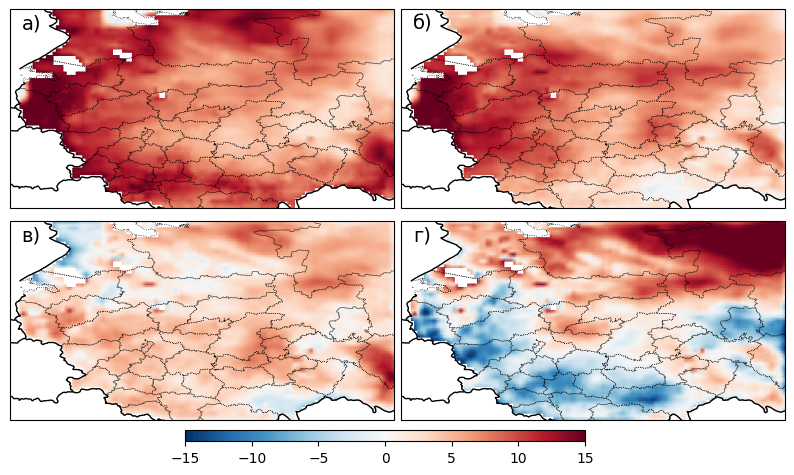

In [83]:
plot_swe_corr(diffs, '123')

In [23]:
def plot_swe_map(dataset, name):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3), subplot_kw={'projection': ccrs.PlateCarree()}, gridspec_kw={'wspace': 0.02, 'hspace': 0.02})
    mesh = draw_swe_map(axes[0], dataset[0], 'a)', -30, 30)
    draw_swe_map(axes[1], dataset[1], 'б)', -30, 30)
    draw_swe_map(axes[2], dataset[2], 'в)', -30, 30)
    print(name)
    fig.subplots_adjust(bottom=-0.05)
    cbar_ax = fig.add_axes([0.3, 0.1, 0.4, 0.02])
    cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal', ticks=np.arange(-30, 31, 5))
    plt.savefig(f'../figures/presentation/{name}.png', dpi=dpi, bbox_inches='tight')
    plt.show()

1991


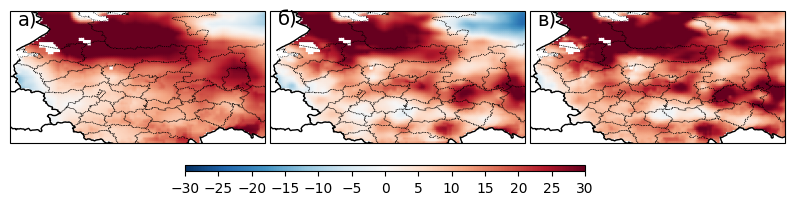

1992


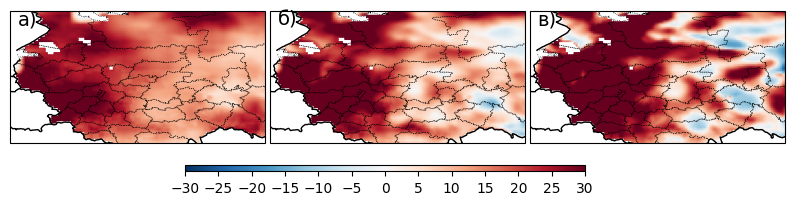

1993


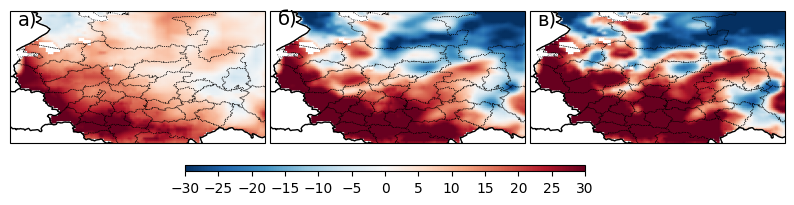

1994


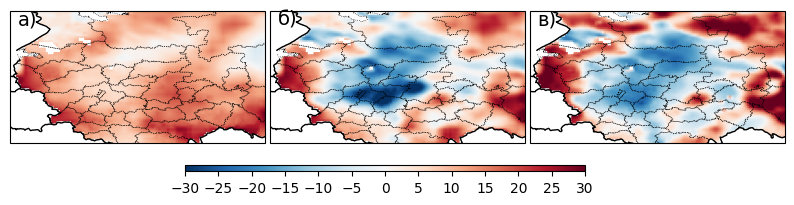

1995


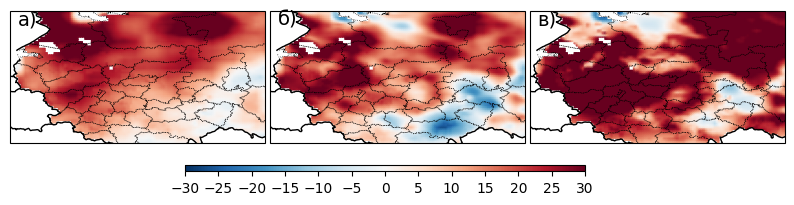

1996


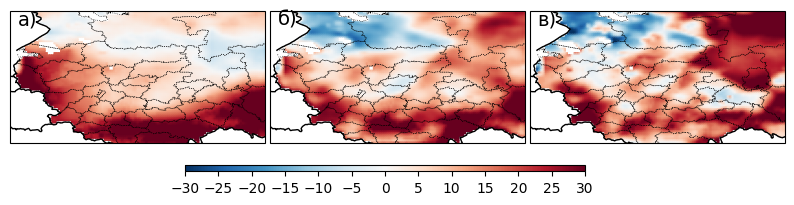

1997


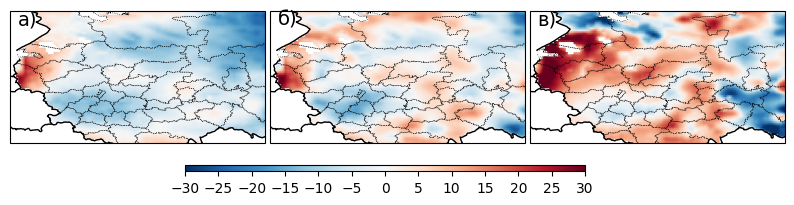

1998


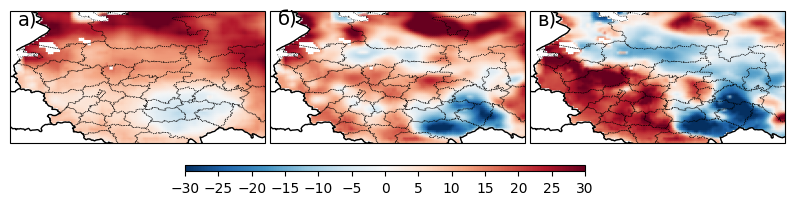

1999


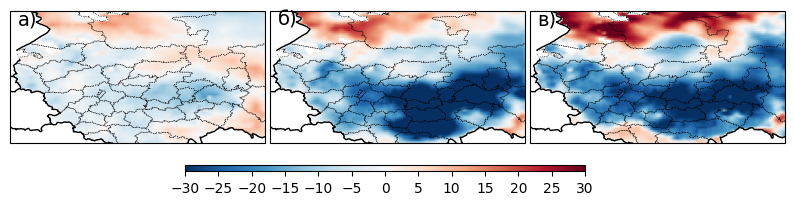

2000


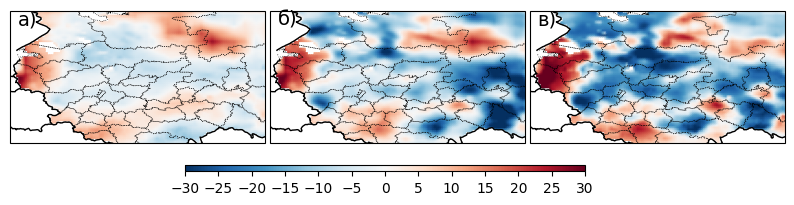

2001


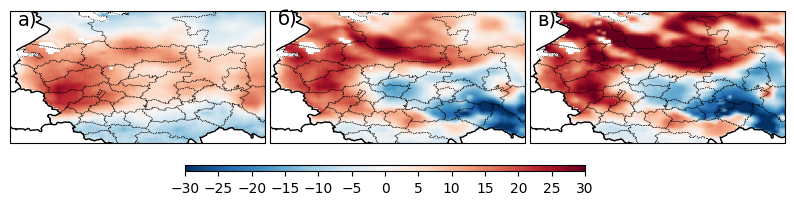

2002


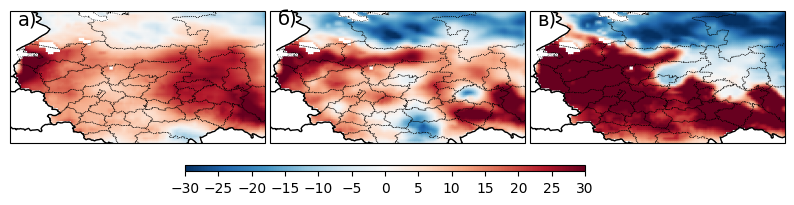

2003


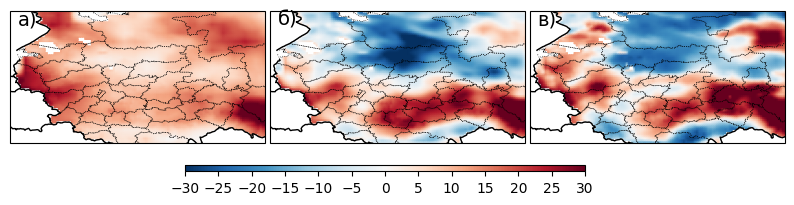

2004


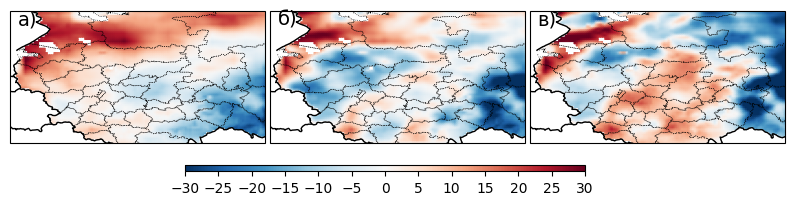

2005


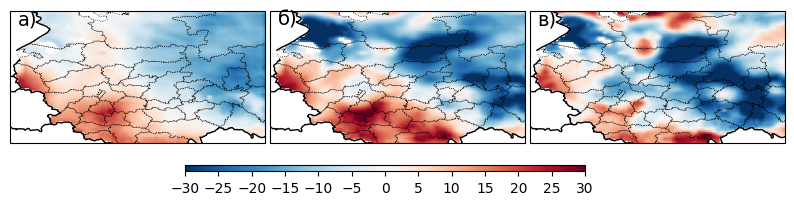

2006


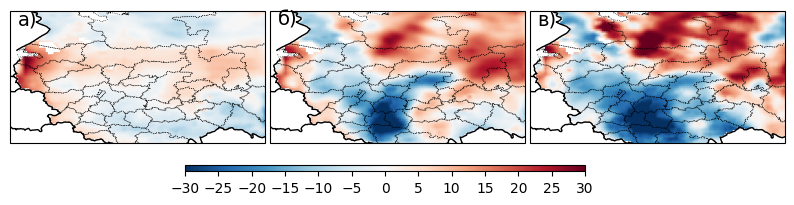

2007


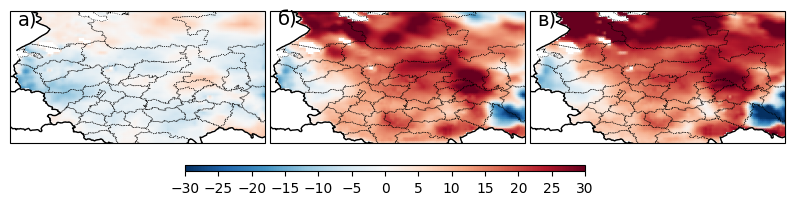

2008


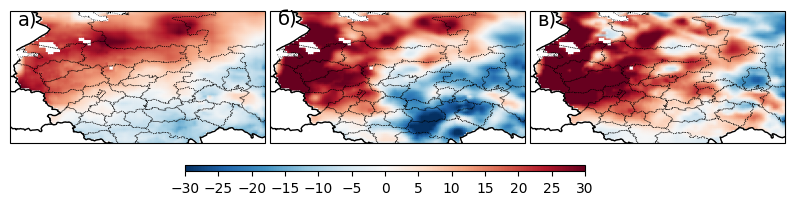

2009


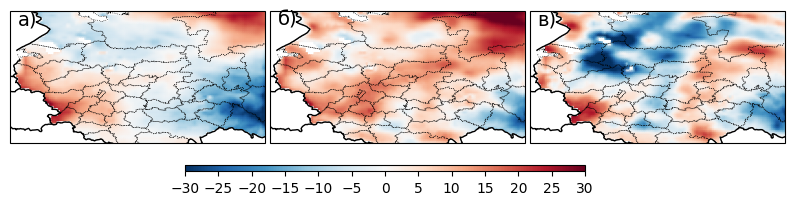

2010


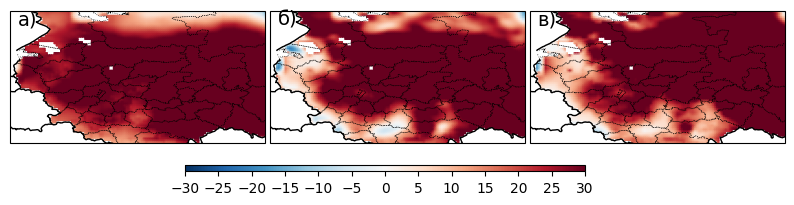

2011


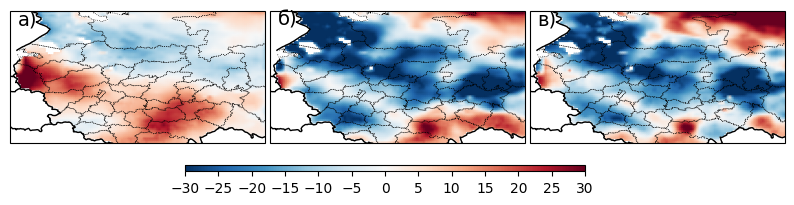

2012


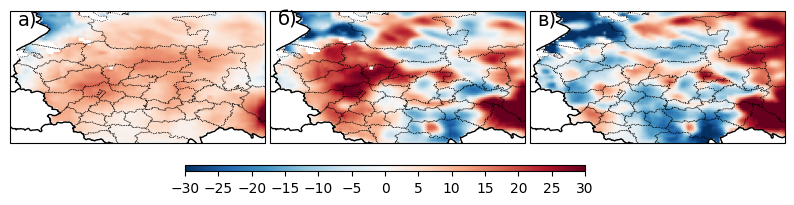

2013


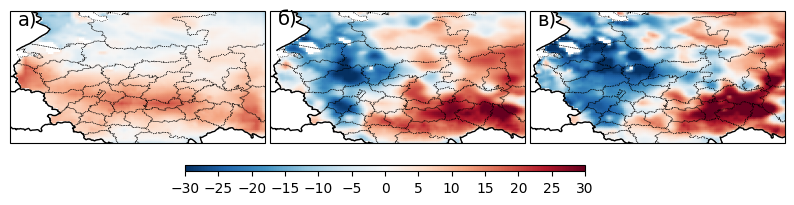

2014


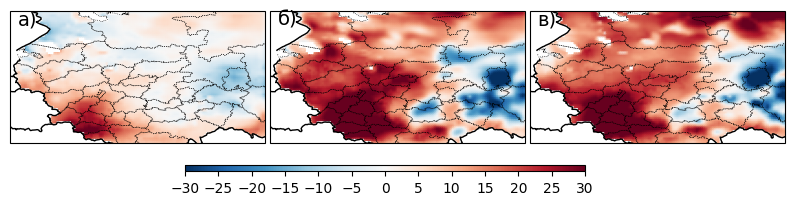

2015


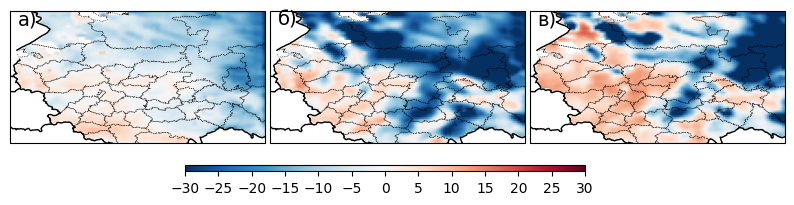

2016


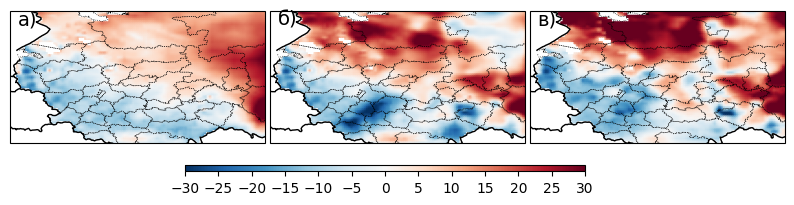

2017


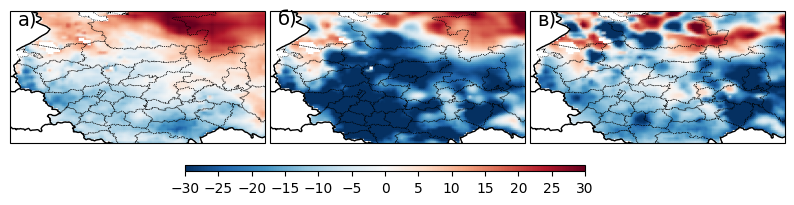

2018


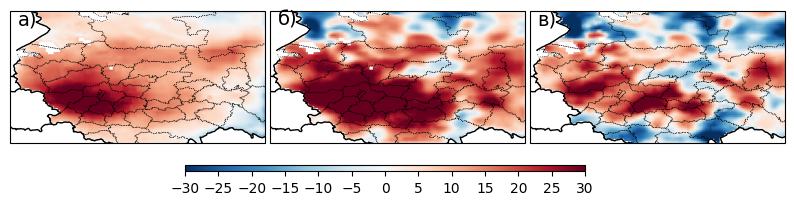

2019


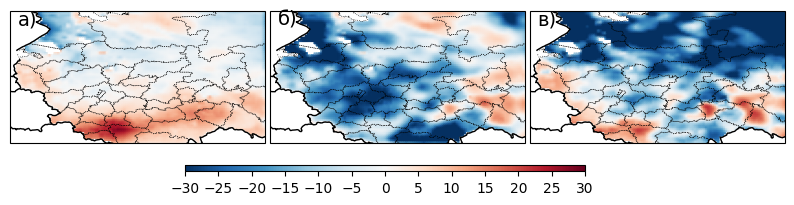

2020


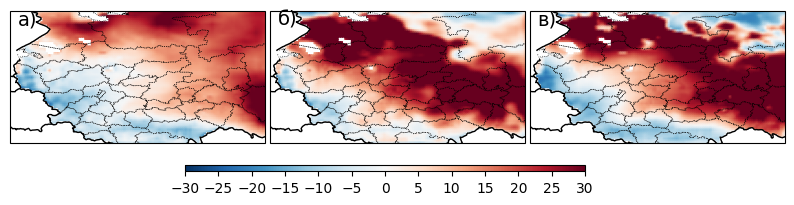

2025


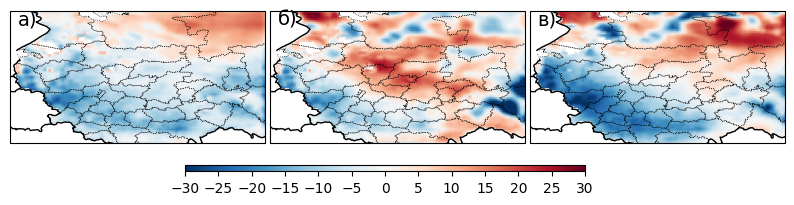

In [25]:
for year in list(range(1991, 2021)) + [2025]:
    df = df4[(df4['year'] == year)]
    if len(df) == 0:
        continue
    diff = df.groupby(['lat', 'lon'])['diff'].mean().reset_index()
    diff_era = df.groupby(['lat', 'lon'])['diff_era'].mean().reset_index().rename(columns={'diff_era': 'diff'})
    diff_swe_era = df.groupby(['lat', 'lon'])['diff_swe_era'].mean().reset_index().rename(columns={'diff_swe_era': 'diff'})
    plot_swe_map([diff, diff_swe_era, diff_era], str(year))